# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

Dataset yang digunakan pada eksperimen ini adalah **Breast Cancer Wisconsin Diagnostic** dari **UCI Machine Learning Repository**. Dataset ini berisi fitur numerik hasil ekstraksi karakteristik inti sel dari citra fine needle aspirate (FNA) massa payudara. Target klasifikasi adalah diagnosis tumor, yaitu **Benign (B)** dan **Malignant (M)**.

- Sumber: UCI Machine Learning Repository
- Nama dataset: Breast Cancer Wisconsin Diagnostic
- File raw: `../breast_cancer_raw/wdbc.data`
- Tujuan pemodelan: klasifikasi biner diagnosis kanker payudara.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RAW_PATH = Path('../breast_cancer_raw/wdbc.data')
OUTPUT_DIR = Path('breast_cancer_preprocessing')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_GROUPS = ('mean', 'se', 'worst')
BASE_FEATURES = (
    'radius', 'texture', 'perimeter', 'area', 'smoothness',
    'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension'
)
FEATURE_COLUMNS = [f'{name}_{group}' for group in FEATURE_GROUPS for name in BASE_FEATURES]
COLUMNS = ['id', 'diagnosis', *FEATURE_COLUMNS]

print('Library berhasil diimpor.')

Library berhasil diimpor.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df = pd.read_csv(RAW_PATH, header=None, names=COLUMNS)

print('Dataset berhasil dimuat.')
print(f'Shape dataset: {df.shape}')
print('Lima baris awal dataset:')
print(df.head())

Dataset berhasil dimuat.
Shape dataset: (569, 32)
Lima baris awal dataset:
         id diagnosis  ...  symmetry_worst  fractal_dimension_worst
0    842302         M  ...          0.4601                  0.11890
1    842517         M  ...          0.2750                  0.08902
2  84300903         M  ...          0.3613                  0.08758
3  84348301         M  ...          0.6638                  0.17300
4  84358402         M  ...          0.2364                  0.07678

[5 rows x 32 columns]


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimet

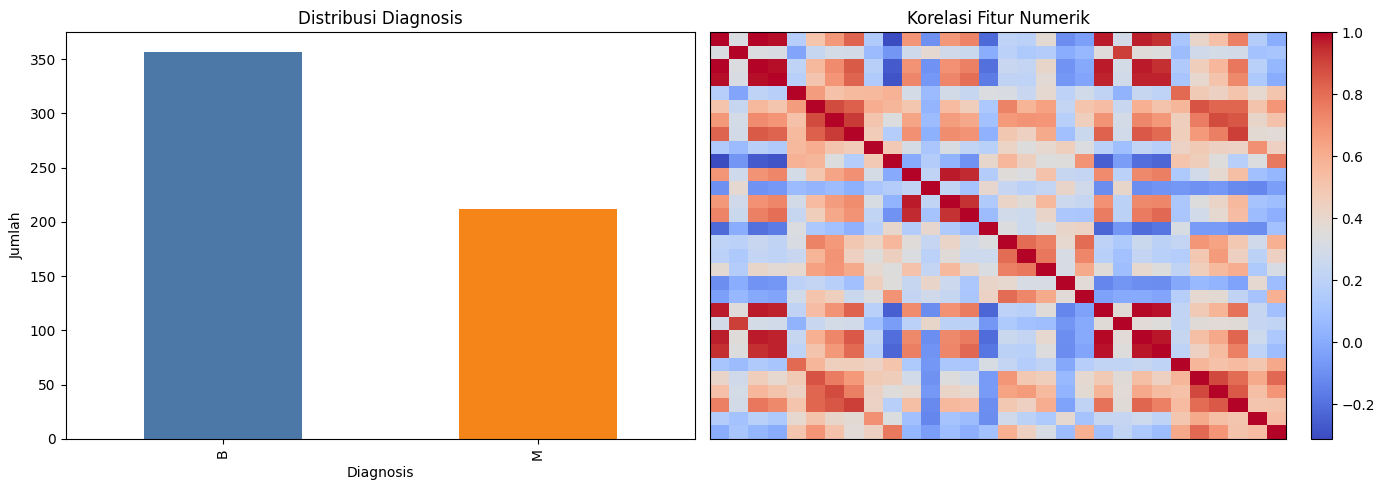

In [3]:
print('Informasi dataset:')
print(df.info())
print('\nStatistik deskriptif 10 fitur pertama:')
print(df.describe().T.head(10))
print('\nDistribusi target diagnosis:')
print(df['diagnosis'].value_counts())
print(f'Jumlah missing values: {int(df.isna().sum().sum())}')
print(f'Jumlah data duplikat: {int(df.duplicated().sum())}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['diagnosis'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['#4c78a8', '#f58518'])
axes[0].set_title('Distribusi Diagnosis')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Jumlah')

corr = df.drop(columns=['id', 'diagnosis']).corr()
im = axes[1].imshow(corr, cmap='coolwarm', aspect='auto')
axes[1].set_title('Korelasi Fitur Numerik')
axes[1].set_xticks([])
axes[1].set_yticks([])
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
processed_df = df.drop(columns=['id']).drop_duplicates().copy()
processed_df['target'] = processed_df['diagnosis'].map({'B': 0, 'M': 1}).astype(int)
processed_df = processed_df.drop(columns=['diagnosis'])

feature_columns = [col for col in processed_df.columns if col != 'target']
scaler = StandardScaler()
processed_df[feature_columns] = scaler.fit_transform(processed_df[feature_columns])

train_df, test_df = train_test_split(
    processed_df,
    test_size=0.2,
    random_state=42,
    stratify=processed_df['target'],
)

processed_df.to_csv(OUTPUT_DIR / 'breast_cancer_processed.csv', index=False)
train_df.to_csv(OUTPUT_DIR / 'train.csv', index=False)
test_df.to_csv(OUTPUT_DIR / 'test.csv', index=False)

print('Preprocessing selesai.')
print(f'Full processed shape: {processed_df.shape}')
print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')
print('File yang disimpan:')
print(OUTPUT_DIR / 'breast_cancer_processed.csv')
print(OUTPUT_DIR / 'train.csv')
print(OUTPUT_DIR / 'test.csv')
print('\nLima baris awal data preprocessing:')
print(processed_df.head())

Preprocessing selesai.
Full processed shape: (569, 31)
Train shape: (455, 31)
Test shape: (114, 31)
File yang disimpan:
breast_cancer_preprocessing\breast_cancer_processed.csv
breast_cancer_preprocessing\train.csv
breast_cancer_preprocessing\test.csv

Lima baris awal data preprocessing:
   radius_mean  texture_mean  ...  fractal_dimension_worst  target
0     1.097064     -2.073335  ...                 1.937015       1
1     1.829821     -0.353632  ...                 0.281190       1
2     1.579888      0.456187  ...                 0.201391       1
3    -0.768909      0.253732  ...                 4.935010       1
4     1.750297     -1.151816  ...                -0.397100       1

[5 rows x 31 columns]
